In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

# Chargement des données

1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea

In [5]:
df = pd.read_csv('..\\data\\housing.csv')

# Traitement des valeurs manquantes
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Encodage de la variable catégorielle 'ocean_proximity'
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Séparation des caractéristiques (X) et de la cible (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Grille de pré-élagage

In [6]:
# Grille de pré-élagage
param_grid = {
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3, 5],
    'min_impurity_decrease': [0.0, 0.01, 0.1]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,               # Validation croisée à 5 blocs
    scoring='r2',       # Optimisation du coefficient de détermination R²
    n_jobs=-1,          # Utilisation de tous les cœurs du processeur
    verbose=1
)

print("Recherche de la meilleure structure d'arbre par validation croisée...")
grid_search.fit(X_train, y_train)

# Extraction du modèle optimal
best_model = grid_search.best_estimator_

print("\n--- MEILLEURS PARAMÈTRES TROUVÉS ---")
for param, val in grid_search.best_params_.items():
    print(f"  • {param}: {val}")

model = best_model

Recherche de la meilleure structure d'arbre par validation croisée...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

--- MEILLEURS PARAMÈTRES TROUVÉS ---
  • max_depth: 12
  • min_impurity_decrease: 0.0
  • min_samples_leaf: 5
  • min_samples_split: 2


# Mesure sur apprentissage

In [7]:
# Prédictions sur l'échantillon d'apprentissage (LS) et de test (TS)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Métriques sur l'échantillon d'apprentissage (LS - Erreur de ré-substitution)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Métriques sur l'échantillon de test (TS - Erreur de généralisation)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("=== ÉVALUATION DE L'ÉCART APPRENTISSAGE / TEST (LS vs TS) ===")
print(f"• LS (Apprentissage) - RMSE : {rmse_train:,.2f} $ | R² : {r2_train:.4f}")
print(f"• TS (Test)          - RMSE : {rmse_test:,.2f} $ | R² : {r2_test:.4f}")
print(f"• Écart R² (LS - TS) : {r2_train - r2_test:.4f}")

# Diagnostic automatique du surapprentissage
if (r2_train - r2_test) > 0.15:
    print("\n⚠Risque de surapprentissage (Overfitting) : le modèle est nettement plus performant sur LS que sur TS.")
elif r2_train < 0.5:
    print("\n⚠Risque de sous-apprentissage (Underfitting) : la complexité du modèle est insuffisante.")
else:
    print("\nBon équilibre : l'écart entre LS et TS reste maîtrisé.")

=== ÉVALUATION DE L'ÉCART APPRENTISSAGE / TEST (LS vs TS) ===
• LS (Apprentissage) - RMSE : 43,604.92 $ | R² : 0.8578
• TS (Test)          - RMSE : 59,308.11 $ | R² : 0.7316
• Écart R² (LS - TS) : 0.1262

Bon équilibre : l'écart entre LS et TS reste maîtrisé.


# Évaluation du modèle

## params :
longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity



In [8]:
y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE (Erreur quadratique moyenne) : {rmse:.2f}")
print(f"Score R² : {r2:.4f}")

RMSE (Erreur quadratique moyenne) : 59308.11
Score R² : 0.7316


# Visualisation

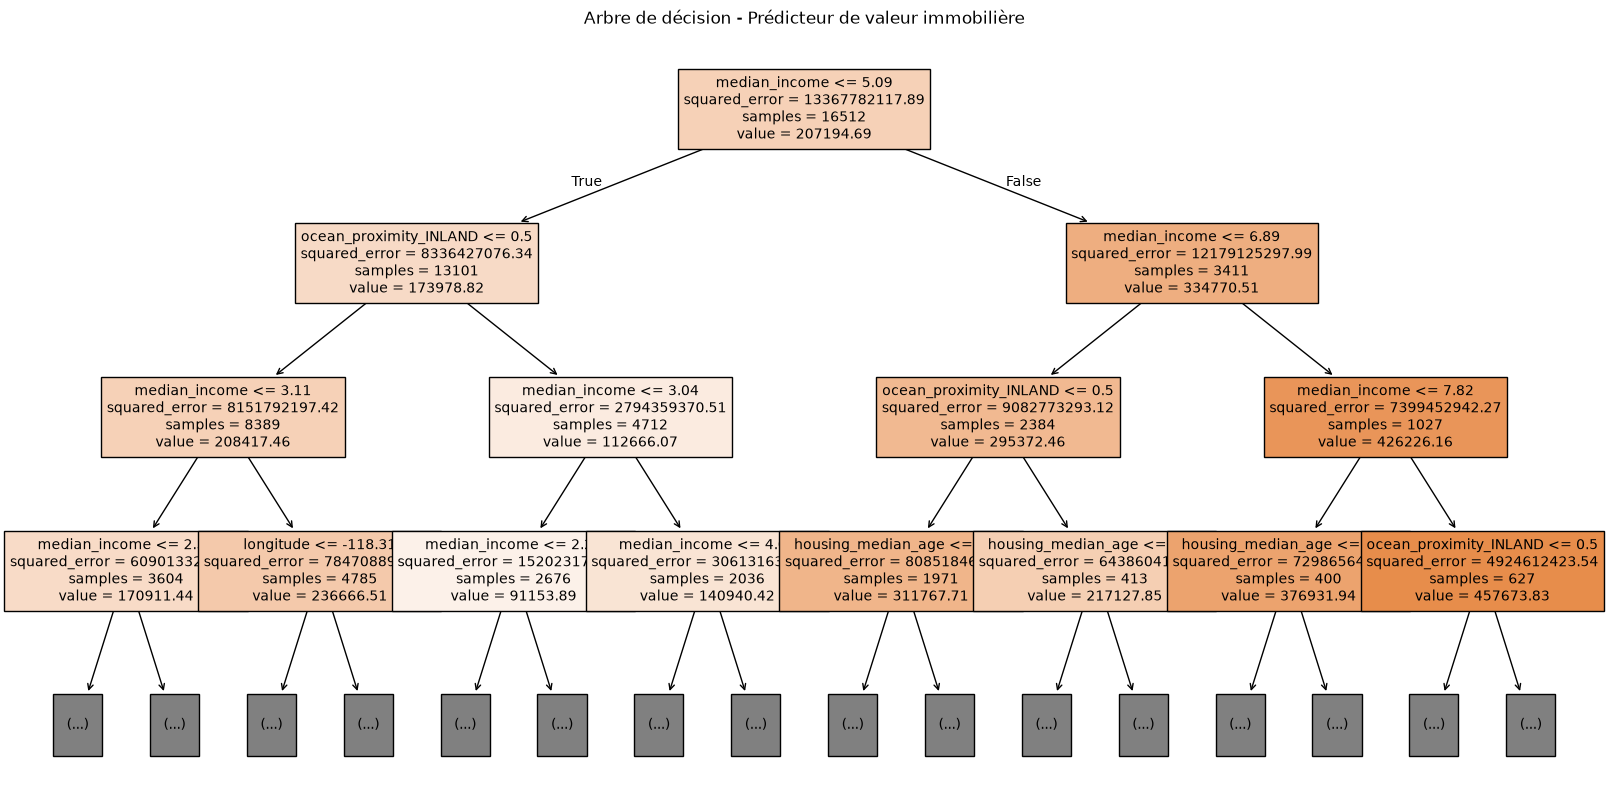

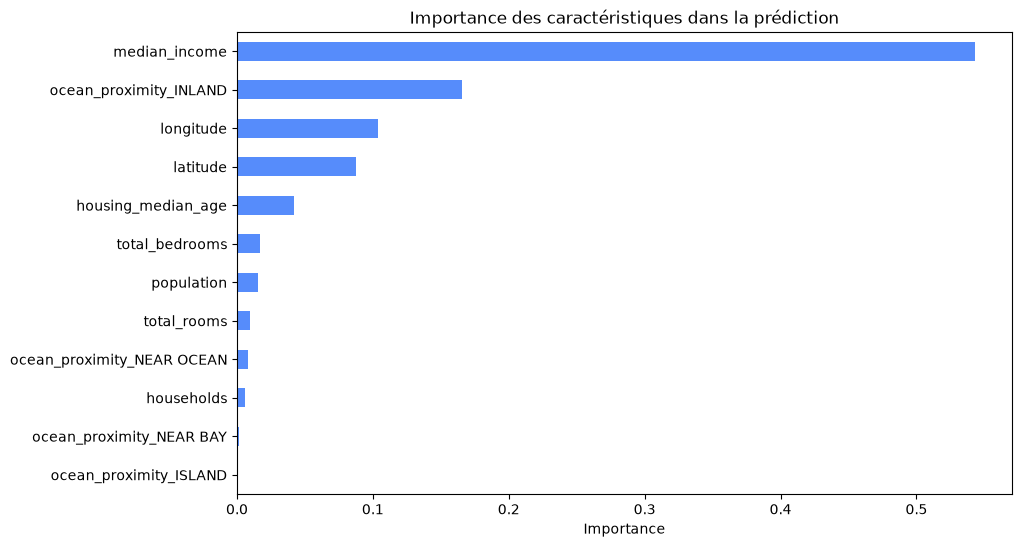

In [9]:
# Visualisation des premiers niveaux de l'arbre
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    max_depth=3,
    fontsize=10,
    precision=2,
)
plt.title("Arbre de décision - Prédicteur de valeur immobilière")
plt.show()

# Importance des variables (Feature Importance)
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Importance des caractéristiques dans la prédiction")
plt.xlabel("Importance")
plt.show()

In [10]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# -------------------------------------------------
# 1. Définition de l'espace de recherche + objectif
# -------------------------------------------------
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1, step=0.001),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 200),
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse', 'absolute_error']),
        'random_state': 42
    }

    model = DecisionTreeRegressor(**params)

    # Validation croisée 5-fold (même scoring que ton GridSearch)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    return scores.mean()   # On maximise le R² moyen

# -------------------------------------------------
# 2. Lancement de l'optimisation bayésienne
# -------------------------------------------------
print("Optimisation bayésienne des hyperparamètres avec Optuna...")

study = optuna.create_study(direction='maximize', study_name='DecisionTree_Housing')
study.optimize(objective, n_trials=50, show_progress_bar=True)   # 50 essais = très bon compromis

print("\n--- MEILLEURS PARAMÈTRES TROUVÉS (Optuna) ---")
for param, val in study.best_params.items():
    print(f"  • {param}: {val}")
print(f"Meilleur R² CV : {study.best_value:.4f}")

# -------------------------------------------------
# 3. Entraînement du modèle optimal
# -------------------------------------------------
best_model = DecisionTreeRegressor(**study.best_params)
best_model.fit(X_train, y_train)

# -------------------------------------------------
# 4. Évaluation (identique à ton code existant)
# -------------------------------------------------
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)

print("\n=== ÉVALUATION LS vs TS (modèle Optuna) ===")
print(f"• LS - RMSE : {rmse_train:,.2f} $ | R² : {r2_train:.4f}")
print(f"• TS - RMSE : {rmse_test:,.2f} $ | R² : {r2_test:.4f}")
print(f"• Écart R² (LS - TS) : {r2_train - r2_test:.4f}")

# Diagnostic
if (r2_train - r2_test) > 0.15:
    print("\n⚠ Risque de surapprentissage.")
elif r2_train < 0.5:
    print("\n⚠ Risque de sous-apprentissage.")
else:
    print("\nBon équilibre.")

[I 2026-09-21 10:02:22,048] A new study created in memory with name: DecisionTree_Housing


Optimisation bayésienne des hyperparamètres avec Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]C:\HEPL_2026\Algorithmique\MASI5_PROJET1_ALGO\venv\Lib\site-packages\sklearn\tree\_classes.py:1347: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warnings.warn(
Best trial: 0. Best value: 0.716033:   2%|▏         | 1/50 [00:00<00:08,  5.74it/s]

[I 2026-09-21 10:02:22,220] Trial 0 finished with value: 0.7160333306582605 and parameters: {'max_depth': 26, 'min_samples_split': 44, 'min_samples_leaf': 15, 'min_impurity_decrease': 0.006, 'max_leaf_nodes': 106, 'criterion': 'friedman_mse'}. Best is trial 0 with value: 0.7160333306582605.


Best trial: 0. Best value: 0.716033:   6%|▌         | 3/50 [00:00<00:12,  3.81it/s]

...

[I 2026-09-21 10:02:30,183] Trial 45 finished with value: 0.7290285747564326 and parameters: {'max_depth': 20, 'min_samples_split': 33, 'min_samples_leaf': 20, 'min_impurity_decrease': 0.085, 'max_leaf_nodes': 185, 'criterion': 'squared_error'}. Best is trial 33 with value: 0.7319951505505685.
[I 2026-09-21 10:02:30,349] Trial 46 finished with value: 0.727137656776339 and parameters: {'max_depth': 25, 'min_samples_split': 20, 'min_samples_leaf': 28, 'min_impurity_decrease': 0.092, 'max_leaf_nodes': 176, 'criterion': 'squared_error'}. Best is trial 33 with value: 0.7319951505505685.


Best trial: 33. Best value: 0.731995:  98%|█████████▊| 49/50 [00:08<00:00,  6.19it/s]

[I 2026-09-21 10:02:30,515] Trial 47 finished with value: 0.7310742560971393 and parameters: {'max_depth': 26, 'min_samples_split': 21, 'min_samples_leaf': 19, 'min_impurity_decrease': 0.1, 'max_leaf_nodes': 195, 'criterion': 'squared_error'}. Best is trial 33 with value: 0.7319951505505685.
[I 2026-09-21 10:02:30,669] Trial 48 finished with value: 0.7283090504000399 and parameters: {'max_depth': 28, 'min_samples_split': 36, 'min_samples_leaf': 28, 'min_impurity_decrease': 0.09, 'max_leaf_nodes': 185, 'criterion': 'squared_error'}. Best is trial 33 with value: 0.7319951505505685.


Best trial: 33. Best value: 0.731995: 100%|██████████| 50/50 [00:08<00:00,  5.69it/s]


[I 2026-09-21 10:02:30,839] Trial 49 finished with value: 0.7269623839151205 and parameters: {'max_depth': 19, 'min_samples_split': 29, 'min_samples_leaf': 20, 'min_impurity_decrease': 0.08600000000000001, 'max_leaf_nodes': 165, 'criterion': 'squared_error'}. Best is trial 33 with value: 0.7319951505505685.

--- MEILLEURS PARAMÈTRES TROUVÉS (Optuna) ---
  • max_depth: 25
  • min_samples_split: 31
  • min_samples_leaf: 23
  • min_impurity_decrease: 0.094
  • max_leaf_nodes: 192
  • criterion: squared_error
Meilleur R² CV : 0.7320

=== ÉVALUATION LS vs TS (modèle Optuna) ===
• LS - RMSE : 53,866.69 $ | R² : 0.7829
• TS - RMSE : 60,089.53 $ | R² : 0.7245
• Écart R² (LS - TS) : 0.0585

Bon équilibre.
